In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt
import matplotlib.pyplot as plt

print(f"PyMC version: {pm.__version__}")


/Users/jonathan/Desktop/mmm-lab/environments/pymc/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


PyMC version: 5.28.1


In [2]:
from mmm_lab.data_generation.baseline import generate_baseline_geo_data
from mmm_lab.data_generation.marketing import add_marketing_effects

np.random.seed(42)
baseline_df = generate_baseline_geo_data(n_geos=40, n_weeks=104, start_date='2023-01-01')
df = add_marketing_effects(baseline_df, channels=['tv', 'paid_search'])

ground_truth = df.attrs['channel_params']
national_truth_tv = df['effect_tv'].sum() / df['spend_tv'].sum()
national_truth_ps = df['effect_paid_search'].sum() / df['spend_paid_search'].sum()
print(f"National ROAS — TV: {national_truth_tv:.3f}, PS: {national_truth_ps:.3f}")



GROUND TRUTH MARKETING EFFECTS

TV:
  Total Spend:        $10,490,532
  Total Effect:       11,330,600 bookings
  Overall ROAS:       $1.08
  Avg Saturation:     47.3%
  Adstock Rate:       50.0% (carryover)
  Half-Sat Point (K): $5,000
  Shape (S):          1.0

PAID_SEARCH:
  Total Spend:        $8,502,293
  Total Effect:       19,381,451 bookings
  Overall ROAS:       $2.28
  Avg Saturation:     58.5%
  Adstock Rate:       30.0% (carryover)
  Half-Sat Point (K): $2,000
  Shape (S):          1.5

National ROAS — TV: 1.080, PS: 2.280


In [3]:
df_sorted = df.sort_values(['geo', 'date'])
n_geos = df['geo'].nunique()
n_time = df['date'].nunique()

tv_spend_matrix = df_sorted['spend_tv'].values.reshape(n_geos, n_time)
ps_spend_matrix = df_sorted['spend_paid_search'].values.reshape(n_geos, n_time)
y_matrix        = df_sorted['total_bookings'].values.reshape(n_geos, n_time)
pop_weights     = df_sorted.groupby('geo')['population'].first().values
pop_weights     = pop_weights / pop_weights.sum()   # shape (n_geos,)

print(f"Data shape: {y_matrix.shape}")
print(f"y range: {y_matrix.min():.0f} – {y_matrix.max():.0f}")
print(f"TV spend range: ${tv_spend_matrix.min():.0f} – ${tv_spend_matrix.max():.0f}")


Data shape: (40, 104)
y range: 1055 – 25185
TV spend range: $664 – $6021


In [4]:
def geometric_adstock_panel(spend_matrix, alpha):
    """Adstock per geo simultaneously. spend_matrix: (n_geos, n_time)."""
    spend_t = pt.as_tensor_variable(spend_matrix).astype('float64')

    def step(spend_at_t, adstock_prev, alpha):
        return spend_at_t + alpha * adstock_prev

    adstocked = pytensor.scan(
        fn=step,
        sequences=[spend_t.T],
        outputs_info=[pt.zeros((n_geos,))],
        non_sequences=[alpha],
        return_updates=False,
    )
    return adstocked.T   # (n_geos, n_time)

def hill_saturation(x, ec, slope):
    """Hill function: x^slope / (x^slope + ec^slope). Returns values in [0, 1]."""
    return (x**slope) / (x**slope + ec**slope)



In [5]:
pop_w = pt.as_tensor_variable(pop_weights).astype('float64')  # (n_geos,)

with pm.Model() as mmm:
    # === Adstock ===
    alpha_tv = pm.Beta('alpha_tv', alpha=2, beta=2)
    alpha_ps = pm.Beta('alpha_ps', alpha=2, beta=2)

    # === Saturation (ec = K in dollar terms) ===
    ec_tv = pm.HalfNormal('ec_tv', sigma=10000)
    ec_ps = pm.HalfNormal('ec_ps', sigma=10000)

    # === National beta (bookings ceiling) ===
    beta_tv = pm.HalfNormal('beta_tv', sigma=300000)
    beta_ps = pm.HalfNormal('beta_ps', sigma=400000)

    # === Geo baselines ===
    alpha_geo = pm.Normal('alpha_geo', mu=0, sigma=y_matrix.std(), shape=n_geos)

    # === Transformations ===
    tv_adstocked = geometric_adstock_panel(tv_spend_matrix, alpha_tv)  # (n_geos, n_time)
    ps_adstocked = geometric_adstock_panel(ps_spend_matrix, alpha_ps)

    # Standard formula: effect = beta * pop_weight * hill(adstock)
    # TV: slope=1.0, PS: slope=1.5 (matching DGP)
    tv_sat = hill_saturation(tv_adstocked, ec_tv, slope=1.0)
    ps_sat = hill_saturation(ps_adstocked, ec_ps, slope=1.5)

    tv_effect = beta_tv * pop_w[:, None] * tv_sat   # (n_geos, n_time)
    ps_effect = beta_ps * pop_w[:, None] * ps_sat

    mu = alpha_geo[:, None] + tv_effect + ps_effect
    sigma = pm.HalfNormal('sigma', sigma=y_matrix.std())
    pm.Normal('y', mu=mu, sigma=sigma, observed=y_matrix)

print(mmm.free_RVs)


[alpha_tv, alpha_ps, ec_tv, ec_ps, beta_tv, beta_ps, alpha_geo, sigma]


In [6]:
with mmm:
    trace = pm.sample(draws=1000, tune=1000, chains=4,
                      target_accept=0.9, random_seed=42)

print(az.summary(trace, var_names=['alpha_tv', 'alpha_ps', 'ec_tv', 'ec_ps', 
                                    'beta_tv', 'beta_ps'])[['mean', 'sd', 'r_hat']])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_tv, alpha_ps, ec_tv, ec_ps, beta_tv, beta_ps, alpha_geo, sigma]


/Users/jonathan/Desktop/mmm-lab/environments/pymc/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning:
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 345 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


                mean         sd  r_hat
alpha_tv       0.849      0.009   1.00
alpha_ps       0.321      0.015   1.00
ec_tv      35292.413   5553.387   1.00
ec_ps       1804.996    132.425   1.01
beta_tv   158414.227  16571.143   1.00
beta_ps   354059.754  14395.724   1.01


In [7]:
alpha_tv_s = trace.posterior['alpha_tv'].values.flatten()
alpha_ps_s = trace.posterior['alpha_ps'].values.flatten()
ec_tv_s    = trace.posterior['ec_tv'].values.flatten()
ec_ps_s    = trace.posterior['ec_ps'].values.flatten()
beta_tv_s  = trace.posterior['beta_tv'].values.flatten()
beta_ps_s  = trace.posterior['beta_ps'].values.flatten()

n_samples = len(alpha_tv_s)
roas_tv = np.zeros(n_samples)
roas_ps = np.zeros(n_samples)

for i in range(n_samples):
    tv_ads = np.zeros((n_geos, n_time))
    ps_ads = np.zeros((n_geos, n_time))
    tv_ads[:, 0] = tv_spend_matrix[:, 0]
    ps_ads[:, 0] = ps_spend_matrix[:, 0]
    for t in range(1, n_time):
        tv_ads[:, t] = tv_spend_matrix[:, t] + alpha_tv_s[i] * tv_ads[:, t-1]
        ps_ads[:, t] = ps_spend_matrix[:, t] + alpha_ps_s[i] * ps_ads[:, t-1]

    tv_sat = tv_ads / (tv_ads + ec_tv_s[i])
    ps_sat = (ps_ads**1.5) / (ps_ads**1.5 + ec_ps_s[i]**1.5)

    # ROAS = beta * sum(pop_weight[g] * hill[g,t]) / total_spend
    roas_tv[i] = beta_tv_s[i] * (pop_weights[:, None] * tv_sat).sum() / tv_spend_matrix.sum()
    roas_ps[i] = beta_ps_s[i] * (pop_weights[:, None] * ps_sat).sum() / ps_spend_matrix.sum()

print("=== PyMC ROAS Estimates ===")
for name, roas, truth in [('TV', roas_tv, national_truth_tv),
                            ('PS', roas_ps, national_truth_ps)]:
    print(f"\n{name} (ground truth: {truth:.3f}):")
    print(f"  Median: {np.median(roas):.3f}")
    print(f"  90% CI: [{np.percentile(roas,5):.3f}, {np.percentile(roas,95):.3f}]")


=== PyMC ROAS Estimates ===

TV (ground truth: 1.080):
  Median: 0.526
  90% CI: [0.462, 0.596]

PS (ground truth: 2.280):
  Median: 3.011
  90% CI: [2.724, 3.346]


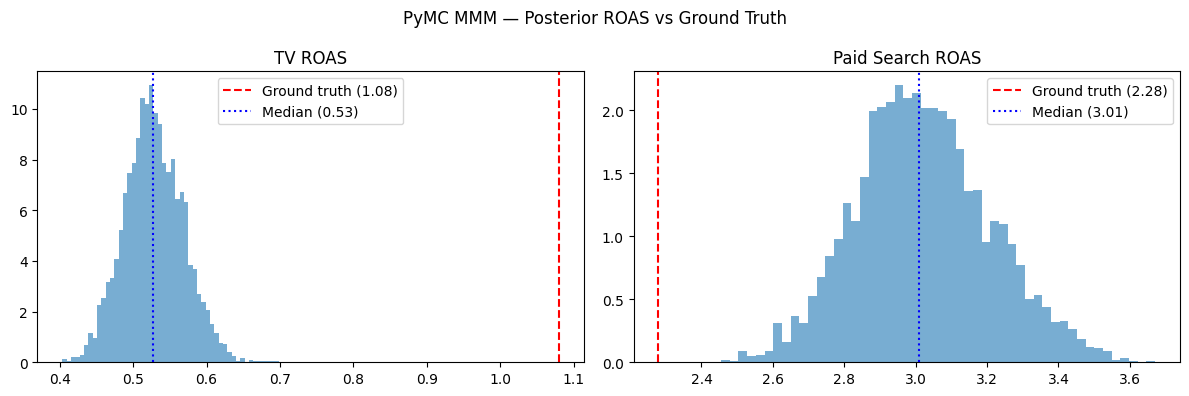

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, roas, truth in [
    (axes[0], 'TV', roas_tv, national_truth_tv),
    (axes[1], 'Paid Search', roas_ps, national_truth_ps),
]:
    ax.hist(roas, bins=50, density=True, alpha=0.6)
    ax.axvline(truth, color='red', linestyle='--', label=f'Ground truth ({truth:.2f})')
    ax.axvline(np.median(roas), color='blue', linestyle=':', label=f'Median ({np.median(roas):.2f})')
    ax.set_title(f'{name} ROAS')
    ax.legend()
plt.suptitle('PyMC MMM — Posterior ROAS vs Ground Truth')
plt.tight_layout()
plt.savefig('plots/pymc_roas_posterior.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


In [9]:
from numpy.linalg import lstsq

X_geo = np.zeros((n_geos * n_time, n_geos))
for g in range(n_geos):
    X_geo[g*n_time:(g+1)*n_time, g] = 1

# OLS doesn't know pop_weights, so no pop scaling here
X = np.column_stack([X_geo,
                     tv_spend_matrix.flatten(),
                     ps_spend_matrix.flatten()])
coefs, _, _, _ = lstsq(X, y_matrix.flatten(), rcond=None)

print("=== Naive OLS with Geo Fixed Effects ===")
print(f"TV ROAS:  {coefs[n_geos]:.3f}  (ground truth: {national_truth_tv:.3f})")
print(f"PS ROAS:  {coefs[n_geos+1]:.3f}  (ground truth: {national_truth_ps:.3f})")


=== Naive OLS with Geo Fixed Effects ===
TV ROAS:  0.139  (ground truth: 1.080)
PS ROAS:  0.940  (ground truth: 2.280)


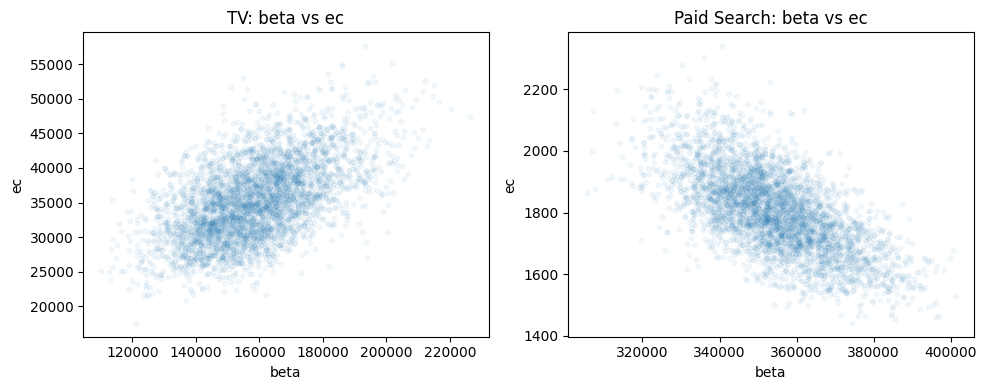

                mean  r_hat
alpha_tv       0.849   1.00
alpha_ps       0.321   1.00
ec_tv      35292.413   1.00
ec_ps       1804.996   1.01
beta_tv   158414.227   1.00
beta_ps   354059.754   1.01


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, b, e, name in [
    (axes[0], trace.posterior['beta_tv'].values.flatten(),
     trace.posterior['ec_tv'].values.flatten(), 'TV'),
    (axes[1], trace.posterior['beta_ps'].values.flatten(),
     trace.posterior['ec_ps'].values.flatten(), 'Paid Search'),
]:
    ax.scatter(b, e, alpha=0.05, s=10)
    ax.set_xlabel('beta')
    ax.set_ylabel('ec')
    ax.set_title(f'{name}: beta vs ec')
plt.tight_layout()
plt.savefig('plots/pymc_beta_ec_correlation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(az.summary(trace, var_names=['alpha_tv', 'alpha_ps', 'ec_tv', 'ec_ps', 
                                    'beta_tv', 'beta_ps'])[['mean', 'r_hat']])


In [11]:
# Compute national ground truth from raw data (verify against attrs)
national_truth_tv = df['effect_tv'].sum() / df['spend_tv'].sum()
national_truth_ps = df['effect_paid_search'].sum() / df['spend_paid_search'].sum()

print("=== National Ground Truth (from data) ===")
print(f"TV ROAS:          {national_truth_tv:.3f}")
print(f"Paid Search ROAS: {national_truth_ps:.3f}")
print(f"\nFrom attrs:")
print(f"TV ROAS:          {ground_truth['tv']['overall_roas']:.3f}")
print(f"Paid Search ROAS: {ground_truth['paid_search']['overall_roas']:.3f}")


=== National Ground Truth (from data) ===
TV ROAS:          1.080
Paid Search ROAS: 2.280

From attrs:
TV ROAS:          1.080
Paid Search ROAS: 2.280


In [12]:
from numpy.linalg import lstsq

# Multi-geo OLS baseline: pool all geos, include geo fixed effects
# No adstock, no saturation — just naive linear model with geo FEs
n_obs = len(df_sorted)
X_geo = np.zeros((n_obs, n_geos))
for g in range(n_geos):
    X_geo[g*104:(g+1)*104, g] = 1  # geo fixed effects

X = np.column_stack([X_geo, tv_spend_matrix.flatten(), ps_spend_matrix.flatten()])
coefs, _, _, _ = lstsq(X, y_matrix.flatten(), rcond=None)

ols_roas_tv = coefs[n_geos]      # TV coefficient
ols_roas_ps = coefs[n_geos + 1]  # PS coefficient

print("=== Naive OLS with Geo Fixed Effects (no adstock, no saturation) ===")
print(f"TV ROAS:          {ols_roas_tv:.3f}  (ground truth: {ground_truth['tv']['overall_roas']:.3f})")
print(f"Paid Search ROAS: {ols_roas_ps:.3f}  (ground truth: {ground_truth['paid_search']['overall_roas']:.3f})")


=== Naive OLS with Geo Fixed Effects (no adstock, no saturation) ===
TV ROAS:          0.139  (ground truth: 1.080)
Paid Search ROAS: 0.940  (ground truth: 2.280)
